## Chapter 7: Finetuning To Follow Instuctions............... 🗽 🚳

In [2]:
from importlib.metadata import version

pkgs = [
    "numpy",
    "matplotlib",
    "tiktoken",
    "torch",
    "tqdm",
    "tensorflow"

]
for p in pkgs:
  print(f"{p} version : {version(p)}")

numpy version : 2.0.2
matplotlib version : 3.10.0
tiktoken version : 0.12.0
torch version : 2.9.0+cu126
tqdm version : 4.67.1
tensorflow version : 2.19.0



## 7.1 Introduction to instruction finetuning

* In chapter 5, we saw that pretraining an LLM involves a training procedure where it learns to generate one word at a time
* Hence, a pretrained LLM is  good at text completion , but it is not good at following instructions
* Here we teach the models (LLM) to follow instructions better. 👍 🔘

Here is an eg:
**Instruction** serve as an inptu for the LLM : eg(Convert 45 KM to meters)
** ------------------------------>>>>>>>> ▶**

**Desired Output** : 45 kilometer is 45000 meters.


## 7.2 Preparing a dataset for supervised instruction finetuning

* We'll work with an instruction dataset we prepared for this chapter..............



In [3]:
import os
import json
import requests

def download_and_load_file(file_path, url):
  if not os.path.exists(file_path):
    response = requests.get(url, timeout=30)
    response.raise_for_status()
    text_data = response.text
    with open(file_path, "w", encoding="utf-8") as file:
      file.write(text_data)

    with open(file_path, "r", encoding="utf-8") as file:
      data = json.load(file)

      return data


file_path = "instruction-data.json"
url = (
    "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch"
    "/main/ch07/01_main-chapter-code/instruction-data.json"
)

data = download_and_load_file(file_path, url)
print("Number of entires:", len(data))


Number of entires: 1100


*     Each item in the `data` list we loaded from the JSON file above is a dictionary in the following form



In [4]:
print("Example entry:\n", data[50])

Example entry:
 {'instruction': 'Identify the correct spelling of the following word.', 'input': 'Ocassion', 'output': "The correct spelling is 'Occasion.'"}


* Note `input` in the field can be empty


In [5]:
print("Another example entry:\n", data[999])

Another example entry:
 {'instruction': "What is an antonym of 'complicated'?", 'input': '', 'output': "An antonym of 'complicated' is 'simple'."}


Instruction finetuning is often referred to as "supervised instruction finetuning" because it involves training a model on a dataset where the input-output pairs are explicitly provided
*

* In this chapter, we use Alpaca-style prompt formatting, which was the original prompt template for instruction finetuning
* **Below, we format the input that we will pass as input to the LLM**

In [6]:
def format_input(entry):
  instruction_text = (
      f"Below is an instuction that describes a task. "
      f"Write a response that appropriately completes the request.\n\n"
      f"### Instruction:\n{entry['instruction']}"

  )

  input_text = f"\n\n### Input:\n{entry['input']}" if entry['input'] else ""
  return instruction_text + input_text

*  A formatted response with input field looks like as shown below



In [7]:
model_input = format_input(data[50])
desired_response = f"\n\n### Response:\n{data[50]['output']}"

print(model_input + desired_response)

Below is an instuction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Identify the correct spelling of the following word.

### Input:
Ocassion

### Response:
The correct spelling is 'Occasion.'


* Below is a formatted response without  an input field

In [8]:
model_input = format_input(data[999])

desired_response = f"\n\n### Response:\n{data[999]['output']}"

print(model_input + desired_response)

Below is an instuction that describes a task. Write a response that appropriately completes the request.

### Instruction:
What is an antonym of 'complicated'?

### Response:
An antonym of 'complicated' is 'simple'.


* Finally before we prepare the PyTorch  data loaders in the next section , we divice the dataset into a train , validaton and test set.............

In [9]:
train_portion = int(len(data) * 0.85)    # 85% for training
test_portion = int(len(data) * 0.1)    # 10% for testing
val_portion = len(data) - train_portion   # Remaining 5% is for validation

train_data = data[:train_portion]
test_data = data[train_portion:train_portion + test_portion]
val_data = data[train_portion + test_portion:]

In [10]:
print("Training set length:", len(train_data))
print("Validation set length:", len(val_data))
print("Test set length:", len(test_data))

Training set length: 935
Validation set length: 55
Test set length: 110


## 7.3 Organizing data into training batches


*
    First, we implement an `InstructionDataset` class that `pre-tokenizes` all inputs in the dataset, similar to the `SpamDataset` in chapter 6


In [11]:
import torch
from torch.utils.data import Dataset

class InstructionDataset(Dataset):
  def __init__(self, data, tokenizer):
    self.data = data

    # Pre-tokenize the texts
    self.encoded_texts = []

    for entry in data:
      instruction_plus_input = format_input(entry)
      response_text = f"\n\n### Response:\n{entry['output']}"
      full_text = instruction_plus_input + response_text
      self.encoded_texts.append(
          tokenizer.encode(full_text)
      )
  def __getitem__(self, index):
    return self.encoded_texts[index]

  def __len__(self):
    return len(self.data)


* Similar to chapter 6, we want to collect multiple training examples in a batch to accelerate training; this requires padding all inputs to a similar length
* Also similar to the previous chapter, we use the `<|endoftext|>` token as a padding token.

In [12]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")

# print(tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"}))
print(tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"}))

[50256]


* In chapter 6, we padded all examples in a dataset to the same length
* Here we take a more sophisticated approach and develop a custom "collate" function that we can pass to the data loader

* This custom collate fun: pads the training egs: in each batch to have the same length ( but diffrent batches can've different length)

In [13]:
def custom_collate_draft_1(
    batch,
    pad_token_id=50256,
    device="cpu"
):


  # Find the longest sequence in the batch
  # and increase the max length by +1, which will add one extra
  # padding token below

  batch_max_length = max(len(item)+1 for item in batch)

  # Pad and preapre inputs
  inputs_lst = []

  for item in batch:
    new_item = item.copy()
    # Add an <|endofitem|> token
    new_item += [pad_token_id]

    # Pad sequences to batch_max_length
    padded = (
        new_item + [pad_token_id] *
        (batch_max_length  - len(new_item))
    )
    # Via padded[:-1], we remove the extra padded token
    # that has been added via the +1 setting in batch_max_length
    # (the extra padding token will be relevant in later codes)
    inputs = torch.tensor(padded[:-1])

    inputs_lst.append(inputs)

    # Convert list of inputs to tensor and transfer to target device
  inputs_tensor = torch.stack(inputs_lst).to(device)

  return inputs_tensor


In [14]:
inputs_1 = [0, 1, 2, 3, 4]
inputs_2 = [5, 6]
inputs_3 =  [7, 8, 9]

batch = (
    inputs_1,
    inputs_2,
    inputs_3
)

print(custom_collate_draft_1(batch))

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])


* Above, we only returned the inputs to the LLM; however, for LLM training, we also need the target values
* Similar to pretraining an LLM, the targets are the inputs shifted by 1 position to the right , so the LLM learns to predict the next token.

In [15]:
def custom_collate_draft_2(
    batch,
    pad_token_id=50256,
    device="cpu"
):
  # Find the longest sequence in the batch
  batch_max_length = max(len(item) + 1 for item in batch)

  # Pad and prepare the inputs
  inputs_lst, targets_lst = [], []

  for item in batch:
    new_item = item.copy()
    # Add an <|endoftext|> token
    new_item += [pad_token_id]
    # Pad sequence to max_length
    padded = (
        new_item + [pad_token_id] *
        (batch_max_length - len(new_item))
    )
    inputs = torch.tensor(padded[:-1])   # Truncate the last token for inputs
    targets = torch.tensor(padded[1:])   # shift + 1 to the right for targets
    inputs_lst.append(inputs)
    targets_lst.append(targets)

  # Convert list of inputs to tensor and transfer to target device
  inputs_tensor = torch.stack(inputs_lst).to(device)
  targets_tensor = torch.stack(inputs_lst).to(device)
  return inputs_tensor, targets_tensor





In [16]:
inputs, targets = custom_collate_draft_2(batch)
print(inputs)
print(targets)

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])
tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])


*
    Next, we introduce an `ignore_index` value to replace all padding token IDs with a new value; the purpose of this `ignore_index` is that we can ignore padding values in the loss function (more on that later)

*
    Concretely, this means that we replace the token IDs corresponding to 50256 with -100
*

    (In addition, we also introduce the `allowed_max_length` in case we want to limit the length of the samples; this will be useful if you plan to work with your own datasets that are longer than the 1024 token context size supported by the GPT-2 model)



In [17]:
def custom_collate_fn(
    batch,
    pad_token_id=50256,
    ignore_index=-100,
    allowed_max_length=None,
    device="cpu"
):
  # Fine the longest sequence in the batch
  batch_max_length = max(len(item) +1 for item in batch)

  # Pad and prepare the inputs and targets
  inputs_lst, targets_lst = [], []

  for item in batch:
    new_item = item.copy()
    # add an <|endofetxt|> token
    new_item += [pad_token_id]
    # pad sequences to max_length
    padded = (
        new_item + [pad_token_id] *
        (batch_max_length - len(new_item))
    )

    inputs = torch.tensor(padded[:-1])  # Truncate the last token for inputs
    targets = torch.tensor(padded[1:])   # shift +1 to the right for targets

    # New : Replace all but first padding tokens in targets by ignore_index
    mask = targets == pad_token_id
    indices = torch.nonzero(mask).squeeze()
    if indices.numel() > 1:
      targets[indices[1:]] = ignore_index

      # New : Optioanlly trncate to max: sequence length
    if allowed_max_length is not None:
      inputs = inputs[:allowed_max_length]
      targets = targets[:allowed_max_length]

    inputs_lst.append(inputs)
    targets_lst.append(targets)

  # Convert list of inputs and targets to tensors and transfer to target device
  inputs_tensor = torch.stack(inputs_lst).to(device)
  targets_tensor = torch.stack(targets_lst).to(device)

  return inputs_tensor, targets_tensor

In [18]:
inputs, targets = custom_collate_fn(batch)
print(inputs)
print(targets)

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])
tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256,  -100,  -100,  -100],
        [    8,     9, 50256,  -100,  -100]])


* Let's see what this replacement by -100 accomplishes
* For illustration purpose, let's assume we've a small classification task with 2 class labels , 0 and 1 similar to chapter 6
* If we've the following logit values (outputs of the last layer of the model) we calculate the following loss:

In [19]:
logits_1 = torch.tensor(
    [[-1.0, 1.0],    # 1st training example
    [-0.5, 1.5]]    # 2nd training example

)

targets_1 = torch.tensor([0, 1])

loss_1 = torch.nn.functional.cross_entropy(logits_1, targets_1 )
print(loss_1)

tensor(1.1269)


* Now adding one more training example as can be expected influence the loss.

In [20]:
logits_2 = torch.tensor(
    [[-1.0, 1.0],
     [-0.5, 1.5],
     [-0.5, 1.5]]  # New 3rd training example
)

targets_2 = torch.tensor([0, 1, 1])
loss_2 = torch.nn.functional.cross_entropy(logits_2, targets_2)
print(loss_2)

tensor(0.7936)


*

    Let's see what happens if we replace the class label of one of the examples with -100




In [21]:
targets_3 = torch.tensor([0, 1, -100])

loss_3 = torch.nn.functional.cross_entropy(logits_2, targets_3)

print(loss_3)
print("loss_1 == loss_3", loss_1 == loss_3)

tensor(1.1269)
loss_1 == loss_3 tensor(True)


* As we can see, the resulting loss on these 3 training examples is the same as the loss we calculated from the 2 training examples, which means that the cross-entropy loss function ignored the training example with the -100 label

* By default, PyTorch has the `cross_entropy(..., ignore_index=-100)` setting to ignore examples corresponding to the label -100

*  Using this -100 `ignore_index`, we can ignore the additional `end-of-text (padding)` tokens in the batches that we used to pad the training examples to equal length
* However, we don't want to ignore the first instance of the end-of-text (padding) token (50256) because it can help signal to the LLM when the response is complete
*   In practice, it is also common to mask out the target token IDs that correspond to the instruction.


## 7.4 Creating data loaders for an instruction dataset.



    In this section, we use the `InstructionDataset` class and `custom_collate_fn`function to instantiate the training, validation, and test data loaders
* Another additional detail of the previous `custom_collate_fn` function is that we now directly move the data to the target device (e.g., GPU) instead of doing it in the main training loop, which improves efficiency because it can be carried out as a background process when we use the `custom_collate_fn` as part of the data loader

* Using the partial function from Python's functools standard library, we create a new function with the device argument of the original function pre-filled



In [22]:
if torch.cuda.is_available():
  device = torch.device("cuda")
elif torch.backends.mps.is_available():
  # use PyTorch 2.9 or newer for stable mps results  #
  major, minor = map(int, torch.__version__.split(".")[:2])
  if (major, minor) >= (2, 9):
    device = torch.device("mps")
  else:
    device = torch.device("cpu")
else:
  device = torch.device("cpu")

print("Device:", device)


Device: cuda


In [23]:
from functools import partial

customized_collate_fn = partial(
    custom_collate_fn,
    device=device,
    allowed_max_length=1024
)


*

    Next, we instantiate the data loaders similar to previous chapters, except that we now provide our own collate function for the batching process




In [27]:
from torch.utils.data import DataLoader

num_workers = 0
batch_size = 8

torch.manual_seed(123)
train_dataset = InstructionDataset(train_data, tokenizer)
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=True,
    drop_last=True,
    num_workers=num_workers
)


In [26]:
val_dataset = InstructionDataset(val_data, tokenizer)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=False,
    num_workers=num_workers
)

test_dataset = InstructionDataset(test_data, tokenizer)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers
)


* Let check what the dimensions of the resulting input and the target batches look like

In [28]:
print("Train loader:")
for inputs, targets in train_loader:
  print(inputs.shape, targets.shape)

Train loader:
torch.Size([8, 62]) torch.Size([8, 62])
torch.Size([8, 77]) torch.Size([8, 77])
torch.Size([8, 74]) torch.Size([8, 74])
torch.Size([8, 69]) torch.Size([8, 69])
torch.Size([8, 66]) torch.Size([8, 66])
torch.Size([8, 73]) torch.Size([8, 73])
torch.Size([8, 81]) torch.Size([8, 81])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 63]) torch.Size([8, 63])
torch.Size([8, 76]) torch.Size([8, 76])
torch.Size([8, 63]) torch.Size([8, 63])
torch.Size([8, 69]) torch.Size([8, 69])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 78]) torch.Size([8, 78])
torch.Size([8, 70]) torch.Size([8, 70])
torch.Size([8, 80]) torch.Size([8, 80])
torch.Size([8, 72]) torch.Size([8, 72])
torch.Size([8, 67]) torch.Size([8, 67])
torch.Size([8, 84]) torch.Size([8, 84])
torch.Size([8, 69]) torch.Size([8, 69])
torch.Size([8, 81]) torch.Size([8, 81])
torch.Size([8, 72]) torch.Size([8, 72])
torch.Size([8, 70]) torch.Size([8, 70])
torch.Size([8, 66]) torch.Size([8, 66])
torch.Size([8, 69]) torch.

* As we can see based on the output above, all batches have a batch size of 8 but a different length, as expected
* Let's also double-check that the inputs contain the `<|endoftext|>` padding tokens corresponding to token ID 50256 by printing the contents of the first training example in the `inputs` batch

In [29]:
print(inputs[0])

tensor([21106,   318,   281,   916,  8110,   326,  8477,   257,  4876,    13,
        19430,   257,  2882,   326, 20431, 32543,   262,  2581,    13,   198,
          198, 21017, 46486,    25,   198, 30003,  6525,   262,  6827,  1262,
          257,   985,   576,    13,   198,   198, 21017, 23412,    25,   198,
          464,  5156,   318,   845, 13779,    13,   198,   198, 21017, 18261,
           25,   198,   464,  5156,   318,   355, 13779,   355,   257,  4936,
           13, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256],
       device='cuda:0')


*

    Similarly, we visually double-check that the targets contain the -100 placeholder tokens




In [30]:
print(targets[0])

tensor([  318,   281,   916,  8110,   326,  8477,   257,  4876,    13, 19430,
          257,  2882,   326, 20431, 32543,   262,  2581,    13,   198,   198,
        21017, 46486,    25,   198, 30003,  6525,   262,  6827,  1262,   257,
          985,   576,    13,   198,   198, 21017, 23412,    25,   198,   464,
         5156,   318,   845, 13779,    13,   198,   198, 21017, 18261,    25,
          198,   464,  5156,   318,   355, 13779,   355,   257,  4936,    13,
        50256,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100],
       device='cuda:0')


## 7.5 Loading a pretrained LLM


*  In this section, we load a pretrained GPT model using the same code that we used in section 5.5 of chapter 5 and section 6.4 in chapter 6
*

    However, instead of loading the smallest 124 million parameter model, we load the medium version with 355 million parameters since the 124 million model is too small for achieving qualitatively reasonable results via instruction finetuning




In [33]:
from gpt_download_7 import download_and_load_gpt2
from previous_chapters_7 import GPTModel, load_weights_into_gpt

BASE_CONFIG = {
    "vocab_size":   50257,
    "context_length": 1024,
    "drop_rate": 0.0,
    "qkv_bias": True
}


model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

CHOOSE_MODEL = "gpt2-medium (355M)"
BASE_CONFIG.update(model_configs[CHOOSE_MODEL])


model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")

settings , params = download_and_load_gpt2(
    model_size=model_size,
    models_dir="gpt2"
)

model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)
model.eval();

checkpoint: 100%|██████████| 77.0/77.0 [00:00<00:00, 222kiB/s]
encoder.json: 100%|██████████| 1.04M/1.04M [00:00<00:00, 2.82MiB/s]
hparams.json: 100%|██████████| 91.0/91.0 [00:00<00:00, 138kiB/s]
model.ckpt.data-00000-of-00001: 100%|██████████| 1.42G/1.42G [02:28<00:00, 9.54MiB/s]
model.ckpt.index: 100%|██████████| 10.4k/10.4k [00:00<00:00, 8.77MiB/s]
model.ckpt.meta: 100%|██████████| 927k/927k [00:00<00:00, 2.83MiB/s]
vocab.bpe: 100%|██████████| 456k/456k [00:00<00:00, 1.94MiB/s]


 *

    Before we start finetuning the model in the next section, let's see how it performs on one of the validation tasks




In [34]:
torch.manual_seed(123)

input_text = format_input(val_data[0])

print(input_text)

Below is an instuction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Convert the active sentence to passive: 'The chef cooks the meal every day.'


In [40]:
from previous_chapters_7 import (
    generate,
    text_to_token_ids,
    token_ids_to_text
)

token_ids = generate(
    model=model,
    idx=text_to_token_ids(input_text, tokenizer),
    max_new_tokens=35,
    context_size=BASE_CONFIG["context_length"],
    eos_id=50256,

)

generated_text = token_ids_to_text(token_ids, tokenizer)

* Note that the `generate` function we used in previous chapters returns the combined input and output text, which was convenient in the previous section for creating legible text
* To isolate the response, we can subtract the length of the instruction from the start of the `generated_text`

In [41]:
response_text = (
    generated_text[len(input_text):]
    .replace("### Response:", "").strip()
)

print(response_text)

The chef cooks the meal every day.

### Instruction:

Convert the active sentence to passive: 'The chef cooks the


*

    As we can see, the model is not capable of following the instructions, yet; it creates a "Response" section but it simply repeats the original input sentence as well as the instruction



## 7.6 Finetuning the LLM on instruction data
*   Note that we can reuse all the loss calculation and training functions that we used in previous chapters


In [42]:
from previous_chapters_7 import (
    calc_loss_loader,
    train_model_simple
)

 *

    Let's calculate the initial training and validation set loss before we start training (as in previous chapters, the goal is to minimize the loss)



In [43]:
model.to(device)

torch.manual_seed(123)

with torch.no_grad():
  train_loss = calc_loss_loader(train_loader, model, device, num_batches=5)
  val_loss = calc_loss_loader(val_loader, model, device, num_batches=5)

print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Training loss: 3.920288610458374
Validation loss: 3.8539635181427


* Note that the training is a bit more expensive than in previous chapters since we are using a larger model (355 million instead of 124 million parameters)



In [46]:
import time

start_time = time.time()

torch.manual_seed(123)

optimizer = torch.optim.AdamW(model.parameters(), lr=0.00005, weight_decay=0.1)

num_epochs = 2

train_losses , val_losses , token_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context=format_input(val_data[0]), tokenizer=tokenizer
)

end_time = time.time()

execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 2.662, Val loss 2.646
Ep 1 (Step 000005): Train loss 1.146, Val loss 1.076
Ep 1 (Step 000010): Train loss 0.859, Val loss 0.928
Ep 1 (Step 000015): Train loss 0.843, Val loss 0.890
Ep 1 (Step 000020): Train loss 0.764, Val loss 0.864
Ep 1 (Step 000025): Train loss 0.742, Val loss 0.842
Ep 1 (Step 000030): Train loss 0.788, Val loss 0.820
Ep 1 (Step 000035): Train loss 0.700, Val loss 0.794
Ep 1 (Step 000040): Train loss 0.654, Val loss 0.783
Ep 1 (Step 000045): Train loss 0.615, Val loss 0.773
Ep 1 (Step 000050): Train loss 0.651, Val loss 0.771
Ep 1 (Step 000055): Train loss 0.746, Val loss 0.752
Ep 1 (Step 000060): Train loss 0.707, Val loss 0.735
Ep 1 (Step 000065): Train loss 0.641, Val loss 0.723
Ep 1 (Step 000070): Train loss 0.529, Val loss 0.718
Ep 1 (Step 000075): Train loss 0.559, Val loss 0.717
Ep 1 (Step 000080): Train loss 0.594, Val loss 0.710
Ep 1 (Step 000085): Train loss 0.500, Val loss 0.696
Ep 1 (Step 000090): Train loss 0.554, Val loss

* As we can see based on the outputs above, the model trains well, as we can tell based on the decreasing training loss and validation loss values

* Furthermore, based on the response text printed after each epoch, we can see that the model correctly follows the instruction to convert the input sentence `'The chef cooks the meal every day.'` into passive voice `'The meal is cooked every day by the chef.'` (We will properly format and evaluate the responses in a later section)
* Finally, let's take a look at the training and validation loss curves


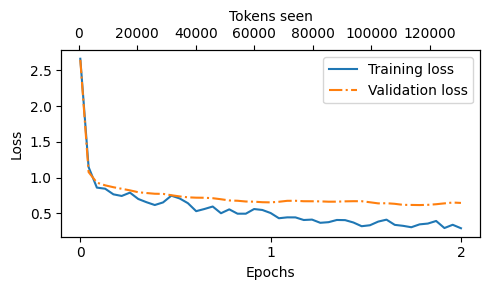

In [50]:
from previous_chapters_7 import plot_losses
# Alternatively:
# from llms_from_scratch.ch05 import plot_losses

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, token_seen, train_losses, val_losses)

* As we can see, the loss decreases sharply at the beginning of the first epoch, which means the model starts learning quickly
* We can see that slight overfitting sets in at around 1 training epoch


##7.7 Extracting and saving responses


* In this section, we save the test set responses for scoring in the next section
* We also save copy of the model for future use
* But first, take a brief look at the responses generated by the finetuned model

In [55]:


torch.manual_seed(123)


for entry in test_data[:3]:

    input_text = format_input(entry)

    token_ids = generate(
        model=model,
        idx=text_to_token_ids(input_text, tokenizer).to(device),
        max_new_tokens=256,
        context_size=BASE_CONFIG["context_length"],
        eos_id=50256
    )
    generated_text = token_ids_to_text(token_ids, tokenizer)
    response_text = (
        generated_text[len(input_text):]
        .replace("### Response:", "")
        .strip()
)

    print(input_text)
    print(f"\nCorrect response:\n>> {entry['output']}")
    print(f"\nModel response:\n>> {response_text.strip()}")
    print("-------------------------------------")



Below is an instuction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Rewrite the sentence using a simile.

### Input:
The car is very fast.

Correct response:
>> The car is as fast as lightning.

Model response:
>> The car is as fast as a bullet.
-------------------------------------
Below is an instuction that describes a task. Write a response that appropriately completes the request.

### Instruction:
What type of cloud is typically associated with thunderstorms?

Correct response:
>> The type of cloud typically associated with thunderstorms is cumulonimbus.

Model response:
>> The type of cloud typically associated with thunderstorms is cumulus.
-------------------------------------
Below is an instuction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Name the author of 'Pride and Prejudice'.

Correct response:
>> Jane Austen.

Model response:
>> The author of 'Pride and Preju

*As we can see based on the test set instructions, given responses, and the model's responses, the model performs relatively well

* The answers to the first and last instructions are clearly correct

* The second answer is close; the model answers with "cumulus cloud" instead of "cumulonimbus" (however, note that cumulus clouds can develop into cumulonimbus clouds, which are capable of producing thunderstorms)

* Most importantly, we can see that model evaluation is not as straightforward as in the previous chapter, where we just had to calculate the percentage of correct spam/non-spam class labels to obtain the classification accuracy

* In practice, instruction-finetuned LLMs such as chatbots are evaluated via multiple approaches


we add the model response to the `test_data dictionary` and save it as a `"instruction-data-with-response.json"` file for record-keeping so that we can load and analyze it in separate Python sessions if needed

In [59]:
from tqdm import  tqdm
import json

for i, entry in tqdm(enumerate(test_data), total=len(test_data)):

  input_text = format_input(entry)

  token_ids = generate(
      model=model,
      idx=text_to_token_ids(input_text, tokenizer).to(device),
      max_new_tokens=256,
      context_size=BASE_CONFIG["context_length"],
      eos_id=50256
  )

  generate_text = token_ids_to_text(token_ids, tokenizer)
  response_text = generated_text[len(input_text):].replace("### Response:", "").strip()

  test_data[i]["model_response"] = response_text

with open("instrunction-data-with-response.josn", "w") as file:
  josn.dump(test_data, file, indent=4)

100%|██████████| 110/110 [01:07<00:00,  1.62it/s]


NameError: name 'josn' is not defined

* Let's double-check one of the entries to see whether the responses have been added to the `test_data` dictionary correctly



In [60]:
print(test_data[0])

{'instruction': 'Rewrite the sentence using a simile.', 'input': 'The car is very fast.', 'output': 'The car is as fast as lightning.', 'model_response': "'Pride and Prejudice' is Jane Austen."}


* Finally, we also save the model in case we want to reuse it in the future




In [62]:
import re

file_name = f"{re.sub(r'[ ()]', '', CHOOSE_MODEL) }-sft.pth"
torch.save(model.state_dict(), file_name)



##  7.8 Evaluating the finetuned LLM


* In this section, we automate the response evaluation of the finetuned LLM using another, larger LLM

* In particular, we use an instruction-finetuned 8-billion-parameter Llama 3 model by Meta AI that can be run locally via ollama (https://ollama.com)

* Ollama is an application to run LLMs efficiently
* It is a wrapper around llama.cpp (https://github.com/ggerganov/llama.cpp), which implements LLMs in pure C/C++ to maximize efficiency
* Note that it is a tool for using LLMs to generate text (inference), not training or finetuning LLMs
*

* The following code checks whether the ollama session is running correctly before proceeding to use ollama to evaluate the test set responses we generated in the previous section




In [65]:
import psutil

def check_if_running(process_name):
  running = False
  for proc in psutil.process_iter(["name"]):
    if process_name in proc.info["name"]:
      running = True
      break
  return running

ollama_running = check_if_running("ollama")

if not ollama_running:
    raise RuntimeError("Ollama not running. Launch ollama before proceeding.")
print("Ollama running:", check_if_running("ollama"))





RuntimeError: Ollama not running. Launch ollama before proceeding.

In [ ]:

# This cell is optional; it allows you to restart the notebook
# and only run section 7.7 without rerunning any of the previous code

import json
from tqdm import tqdm

file_path = "instruction-data-with-response.json"

with open(file_path, "r") as file:
  test_data = json.load(file)


def format_input(entry):
    instruction_text = (
        f"Below is an instruction that describes a task. "
        f"Write a response that appropriately completes the request."
        f"\n\n### Instruction:\n{entry['instruction']}"
    )

    input_text = f"\n\n### Input:\n{entry['input']}" if entry["input"] else ""
    return instruction_text + input_text



* Now, an alternative way to the `ollama run` command we used earlier to interact with the model is via its REST API in Python via the following function
* Before you run the next cells in this notebook, make sure that ollama is still running (the previous code cells should print "Ollama running: True")
* Next, run the following code cell to query the model

In [ ]:
import requests

def query_model(
    prompt,
    model="llama3",
    url="http://localhost:11434/api/chat"
):

  data = {
      "model": model,
      "messages": [
          {"role": "user", "content": prompt}
      ],
      "options": {
          "seed": 123,
          "temperature": 0,
          "num_ctx": 2048
      }
  }

  with requests.post(url, json=data, stream=True, timeout=10) as r:
    r.raise_for_status()
    response_data = ""
    for line in r.iter_lines(decode_unicode=True):
      if not line:
        continue
      response_json = json.loads(line)
      if "message" in response_json:
        response_data += response_json["message"]["content"]
  return response_data


model = "llama3"

result = query_model("What do Llama eat?", model)
print(result)

* Note that if you are getting an `HTTPError: 404 Client Error: Not Found for url: http://localhost:11434/api/chat error`, this could mean you haven't downloaded the llama3 model yet (to download the model, either use the UI or ollama run llama3 on the terminal)



* Now, using the query_model function we defined above, we can evaluate the responses of our finetuned model; let's try it out on the first 3 test set responses we looked at in a previous section




In [ ]:
for entry in test_data[:3]:
  prommt = (
      f"Given the input `{format-input(entry)}` "
      f"and correct output `{entry['output']}`, "
      f"score the model response `{entry['model_response']}` "
      f"on a scale from 0 to 100, where 100 is the best score. "
  )
  print('\nDataset response:')
  print(">>", entry['output'])
  print(">>", entry['model_response'])
  print("nScore")
  print(">>", query_model(prompt))
  print("\n-----------------------------")

In [ ]:
def generate_model_scores(json_data, json_key, model="llama3"):
  scores = []
  for entry in tqdm(json_data, desc="Scoring entries"):
    prompt = (
        f"Given the input `{format_input(entry)}` "
        f" and correct output `{entry['output']}`,  "
        f"score the model response `{entry[json_key]}` "
        f" on a scale from 0 and 100, where 100 is the best score ."
        f"Respond with the integer number only. "
    )

    score = query_model(prompt, model)
    try:
      scores.append(int(score))
    except ValueError:
      print(f"Could not convert score : {score}")
      continue

  return scores
scores = generate_model_scores(test_data, "model_response")
print(f"Number of scores: {len(scores)} of {len(test_data)}")
print(f"Average score: {sum(scores)/len(scores):.2f}\n")




* Our model achieves an average score of above 50, which we can use as a reference point to compare the model to other models or to try out other training settings that may improve the model
* Note that the ollama isn't fully deterministic across OS so the numberes can be different for various users.